In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import gammaln
import sys
from scipy.ndimage import gaussian_filter1d
from scipy.stats import wilcoxon, ranksums
from concurrent import futures 
# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import importlib
import session_class
import cell_analysis
import multi_session_pca
importlib.reload(session_class)
importlib.reload(cell_analysis)
importlib.reload(multi_session_pca)

from session_class import Session
from cell_analysis import Cell
from multi_session_pca import MultiSessionPCA

import holoviews as hv
from holoviews import opts
from bokeh.io import output_notebook
import hvplot.pandas  # noqa: F401
output_notebook()
hv.extension('bokeh')

print("Imports loaded successfully!")

Loading BokehJS ...

Imports loaded successfully!


## 1. Load data and preprocess
1. Load cell metadata
2. Leave only MSN cells 
3. Load the SSRT dataFrame 

In [217]:
base_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data'
# pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'
pickle_file = base_path / 'alt_saccade_params_msn_fiona_cell_trial_data.pkl'

# Load MSN cell database
cell_df = pd.read_pickle(pickle_file)


In [218]:
from scipy.io import savemat
import numpy as np

def df_to_mat_dict(df):
    """Convert a DataFrame to a dict suitable for savemat.
    
    Handles:
    - Numeric columns -> arrays
    - String columns -> cell arrays of strings (object arrays)
    - Columns with variable-length arrays (e.g. neural_data) -> cell arrays
    - Boolean columns -> uint8 arrays
    """
    mat_dict = {}
    for col in df.columns:
        series = df[col]
        
        # Check if column contains variable-length arrays/lists
        sample = series.dropna().iloc[0] if series.notna().any() else None
        
        if sample is not None and isinstance(sample, (list, np.ndarray)):
            # Variable-length arrays -> object array (MATLAB cell array)
            arr = np.empty(len(series), dtype=object)
            for i, val in enumerate(series):
                if isinstance(val, (list, np.ndarray)):
                    arr[i] = np.asarray(val, dtype=np.float64)
                else:
                    arr[i] = np.array([], dtype=np.float64)
            mat_dict[col] = arr
        elif series.dtype == bool or (series.dtype == object and isinstance(sample, (bool, np.bool_))):
            mat_dict[col] = series.astype(np.uint8).values
        elif np.issubdtype(series.dtype, np.number):
            mat_dict[col] = series.values.astype(np.float64)
        else:
            # Strings / categorical -> object array
            arr = np.empty(len(series), dtype=object)
            for i, val in enumerate(series):
                arr[i] = str(val) if val is not None else ''
            mat_dict[col] = arr
    
    return mat_dict

mat_data = df_to_mat_dict(cell_df)
out_path = str(base_path / 'alt_saccade_params_msn_fiona_cell_trial_data.mat')
savemat(out_path, mat_data, do_compression=True)
print(f"Saved {len(cell_df)} rows x {len(cell_df.columns)} columns to {out_path}")

Saved 1939269 rows x 27 columns to /home/barak/Projects/population-analysis/data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.mat


In [143]:
cell_df = cell_df[cell_df['cell_type'] == 'msn']

In [144]:
# for i, row in cell_df.iterrows():
#     if not np.isnan(row['first_relevant_saccade']).any():
#         print(f"Original first_relevant_saccade for cell {row['cell_ID']}: {row['first_relevant_saccade']}")
#         row['first_relevant_saccade'] = row['first_relevant_saccade'] + 30 
#         print(f"Updated first_relevant_saccade for cell {row['cell_ID']}: {row['first_relevant_saccade']}")

In [145]:
ssrt_db = pd.read_excel(base_path.parent / f'SSRT_F.xlsx')[['session', 'Left', 'Right']]

ssrt_db['max'] = ssrt_db.max(axis=1, numeric_only=True)
ssrt_db['max'] = ssrt_db['max'].fillna(ssrt_db['max'].max())

def fix_session_name(name):
    if isinstance(name, str):
        return name.replace("'", '')
    return name
ssrt_db['session'] = ssrt_db['session'].apply(fix_session_name)
ssrt_db = ssrt_db.sort_values('session').reset_index(drop=True)
# ssrt_db['Right'].max()

In [146]:
ssd_per_session = cell_df[cell_df['ssd_number'] < 5].groupby('session').apply(
    lambda x: np.nanmean(x['ssd_len']).astype(int)
).reset_index(name='mean_ssd_len').sort_values('session')

ssd_per_session

,session,mean_ssd_len
0,fi210701,107
1,fi210704,100
2,fi210705,105
3,fi210707,97
4,fi210712,110
5,fi210715,110
6,fi210718,116
7,fi210719,115
8,fi210720,114
9,fi210721,117


In [147]:
ssrt_ssd_df = pd.merge(ssrt_db, ssd_per_session, on='session', how='inner')
# ssrt_ssd_df.iloc[ssrt_ssd_df['Right'].isna()]

ssrt_ssd_df['Right'].fillna(np.nanmean(ssrt_ssd_df['Right']), inplace=True)
ssrt_ssd_df['slow_go_thresh'] = (ssrt_ssd_df['Right'] + ssrt_ssd_df['mean_ssd_len']).astype(int)

ssrt_ssd_df

,session,Left,Right,max,mean_ssd_len,slow_go_thresh
0,fi210701,61.0,107.000000,107.0,107,214
1,fi210704,NaN,87.081633,126.0,100,187
2,fi210705,126.0,87.000000,126.0,105,192
3,fi210707,125.0,120.000000,125.0,97,217
4,fi210712,104.0,95.000000,104.0,110,205
5,fi210715,92.0,121.000000,121.0,110,231
6,fi210718,73.0,117.000000,117.0,116,233
7,fi210719,90.0,100.000000,100.0,115,215
8,fi210720,88.0,91.000000,91.0,114,205
9,fi210721,81.0,108.000000,108.0,117,225


In [148]:
num_of_msn_cells = cell_df[['cell_type', 'cell_ID']].drop_duplicates('cell_ID')['cell_type'].value_counts()['msn']
print(cell_df[['cell_type', 'cell_ID']].drop_duplicates('cell_ID')['cell_type'].value_counts())

cell_df['grade'].value_counts()

cell_type
msn    1302
Name: count, dtype: int64


grade
8    487229
7    219482
6     22363
Name: count, dtype: int64

In [149]:
print(f"Total trials before filtering: {len(cell_df)}")

# Vectorized: merge threshold to mark slow/fast GO trials
cell_df = cell_df.merge(
    ssrt_ssd_df[['session', 'slow_go_thresh']], on='session', how='left'
)

# is_slow_go: True for GO trials at or above threshold, False for GO below threshold, NaN for non-GO
cell_df['is_slow_go'] = np.where(
    cell_df['type'] == 'GO',
    cell_df['slow_go_thresh'].notna() & (cell_df['reaction_time'] >= cell_df['slow_go_thresh']),
    np.nan
)

# is_slow_go: True for CONT trials at or above threshold, False for CONT below threshold
cell_df['is_slow_go'] = np.where(
    (cell_df['type'] == 'CONT') & (cell_df['trial_failed'] == False),
    cell_df['slow_go_thresh'].notna() & (cell_df['reaction_time'] >= cell_df['slow_go_thresh']),
    cell_df['is_slow_go']  # Keep existing values for non-CONT trials
)

# is_slow_go: for error stop trials
cell_df['is_slow_go'] = np.where(
    (cell_df['type'] == 'STOP') & (cell_df['trial_failed'] == True),
    cell_df['slow_go_thresh'].notna() & (cell_df['reaction_time'] >= cell_df['slow_go_thresh']),
    cell_df['is_slow_go']  # Keep existing values else
)


# cell_df = cell_df.drop(columns='slow_go_thresh')

print(f"is_slow_go value counts:\n{cell_df['is_slow_go'].value_counts(dropna=False)}")


Total trials before filtering: 729074
is_slow_go value counts:
is_slow_go
1.0    344512
0.0    271740
NaN    112822
Name: count, dtype: int64


In [150]:
cell_df

,cell_ID,cell_type,maestro_ID,problem,grade,filename,trial_name,reaction_time,go_cue,stop_cue,...,saccades,blinks,dir,neural_data,session,plexon_session,trial_number,trial_session,slow_go_thresh,is_slow_go
0,235,msn,1,NaN,7,fi210927a.0621,STOP_L_SSD2,NaN,908,1016.0,...,"[[179, 210], [355, 445], [460, 473], [704, 728]]","[194, 332]",180,"[233.21, 372.74, 492.74, 725.83, 1434.19]",fi210927,a,621,fi210927a,214,NaN
1,235,msn,1,NaN,7,fi210927a.0578,GO_R,334.0,971,NaN,...,"[[161, 200], [862, 874], [1305, 1339], [1836, ...",None,0,"[36.43, 621.51, 649.88, 657.31]",fi210927,a,578,fi210927a,214,1.0
2,235,msn,1,NaN,7,fi210927a.0642,STOP_L_SSD3,105.0,1045,1213.0,...,"[[202, 239], [1150, 1186], [1653, 1670]]",None,180,[],fi210927,a,642,fi210927a,214,0.0
3,234,msn,2,NaN,7,fi210927a.0133,GO_R,151.0,1078,NaN,...,"[[126, 143], [471, 490], [1229, 1263], [1865, ...",None,0,"[631.53, 632.96, 689.98, 714.21, 1250.43, 2081...",fi210927,a,133,fi210927a,214,0.0
4,235,msn,1,NaN,7,fi210927a.0727,GO_L,181.0,983,NaN,...,"[[114, 152], [488, 504], [1164, 1198]]",None,180,"[778.16, 879.46, 1709.34, 1818.81, 1824.46, 18...",fi210927,a,727,fi210927a,214,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729069,3657,msn,17,NaN,7,fi211110a.2292,STOP_L_SSD3,486.0,1068,1236.0,...,"[[256, 289], [771, 785], [1554, 1565]]",None,180,[],fi211110,a,2292,fi211110a,227,NaN
729070,3665,msn,25,NaN,7,fi211110a.2292,STOP_L_SSD3,486.0,1068,1236.0,...,"[[256, 289], [771, 785], [1554, 1565]]",None,180,"[17.84, 93.98, 151.51, 158.24, 239.59, 262.83,...",fi211110,a,2292,fi211110a,227,NaN
729071,3671,msn,31,NaN,8,fi211110a.2292,STOP_L_SSD3,486.0,1068,1236.0,...,"[[256, 289], [771, 785], [1554, 1565]]",None,180,"[270.68, 784.06, 793.16, 815.51, 903.46, 966.1...",fi211110,a,2292,fi211110a,227,NaN
729072,3673,msn,33,NaN,7,fi211110a.2292,STOP_L_SSD3,486.0,1068,1236.0,...,"[[256, 289], [771, 785], [1554, 1565]]",None,180,[],fi211110,a,2292,fi211110a,227,NaN


In [151]:
# Configuration
# SSRT = 50  # Stop Signal Reaction Time in ms
# SMOOTH_SIGMA = 15  # Smoothing sigma for gaussian filter (ms)
# MIN_GRADE = 8   # Minimum cell quality grade

# Epoch parameters
# BIN_SIZE = 1      # ms
# EPOCH_WINDOW = [-200, 600] # ms around alignment event

"""
From Indra et al., 2020, methods section page 5;380:
The recording cylinder was implanted on the left hemisphere for monkey F(iona)
"""
CONTRA_DIR = 0  # Contra direction for monkey Fiona

# print(f"Configuration set: SSRT={SSRT}ms, Grade>={MIN_GRADE}")


In [152]:
cell_id = 1547
cell_df['cell_ID'] == cell_id
cell = Cell(cell_df[cell_df['cell_ID'] == cell_id])

print(cell.data['trial_number'].nunique() == cell.data.shape[0])
print(cell.data.shape)

cell.data.columns

True
(685, 29)


Index(['cell_ID', 'cell_type', 'maestro_ID', 'problem', 'grade', 'filename',
       'trial_name', 'reaction_time', 'go_cue', 'stop_cue', 'trial_failed',
       'ssd_len', 'ssd_number', 'type', 'first_relevant_saccade',
       'segs_durations', 'segs_times', 'trial_length', 'screen_rotation',
       'saccades', 'blinks', 'dir', 'neural_data', 'session', 'plexon_session',
       'trial_number', 'trial_session', 'slow_go_thresh', 'is_slow_go'],
      dtype='object')

In [153]:
cell.align_spikes_to_event(
    alignment_point='first_relevant_saccade', verbose=True
)

cell.align_spikes_to_event(
    alignment_point='go_cue', verbose=True
)

cell.data.columns

Index(['cell_ID', 'cell_type', 'maestro_ID', 'problem', 'grade', 'filename',
       'trial_name', 'reaction_time', 'go_cue', 'stop_cue', 'trial_failed',
       'ssd_len', 'ssd_number', 'type', 'first_relevant_saccade',
       'segs_durations', 'segs_times', 'trial_length', 'screen_rotation',
       'saccades', 'blinks', 'dir', 'neural_data', 'session', 'plexon_session',
       'trial_number', 'trial_session', 'slow_go_thresh', 'is_slow_go',
       'spikes_aligned_to_first_relevant_saccade', 'spikes_aligned_to_go_cue'],
      dtype='object')

In [154]:
cell.plot_raster(
    epok=[-500, 200],
    alignment_point='first_relevant_saccade',
    # alignment_point='go_cue',
    trial_type='GO',
    success_only=True,
    direction=CONTRA_DIR,
)

:Overlay
   .Curve.I   :Curve   [x]   (y)
   .HeatMap.I :HeatMap   [time,index]   (value)

## 2. First condition filtering:
Critirion #1: a significant firing rate increase around contralateral saccade onset (-100 ms to +100 ms from saccade onset versus baseline from -300 ms to go) on the go trials (one-tailed Wilcoxon signed-rank,P ≤ 0.05)

**A cell would be concidered a type 1 GO neuron iff on contralateral sccades it shows an increase in FR during ±100 ms from saccade onset vs -300 ms to go cue**

In [155]:
def get_trial_spikes_for_Indra_condition_1(trial: pd.Series):
    """Count the amount of spikes"""
    assert trial['type'] == 'GO', "Only GO trials"
    assert trial['is_slow_go'] == True, "Only slow GO trials"
    assert trial['dir'] == CONTRA_DIR, "Only Right trials"
    assert trial['trial_failed'] == False, "Only successful trials"

    baseline_spikes_count = (
        (trial['spikes_aligned_to_go_cue'] >= -300) & 
        (trial['spikes_aligned_to_go_cue'] <= 0)
    ).sum() / 0.3  # Normalize by time window length in seconds to get firing rate

    saccade_spikes_count = (
        (trial['spikes_aligned_to_first_relevant_saccade'] >= -100) & 
        (trial['spikes_aligned_to_first_relevant_saccade'] <= 100)
    ).sum() / 0.2  # Normalize by time window length in seconds to get firing rate

    return baseline_spikes_count, saccade_spikes_count

def get_cell_spike_counts_for_Indra_condition_1(cell: Cell):
    """Count the amount of spikes for all legal trials of the cell"""
    cell.align_spikes_to_event(
        alignment_point='first_relevant_saccade', verbose=True
    )

    cell.align_spikes_to_event(
        alignment_point='go_cue', verbose=True
    )

    tmp_df = cell.data[
        (cell.data['type'] == 'GO') &
        (cell.data['dir'] == CONTRA_DIR) &
        (cell.data['is_slow_go'] == True) &  # Slow-GO trials only
        (cell.data['trial_failed'] == False)
    ]

    spike_counts = tmp_df.apply(get_trial_spikes_for_Indra_condition_1, axis=1, result_type='expand').to_numpy()
    base_line_counts = spike_counts[:, 0]
    saccade_counts = spike_counts[:, 1]

    return base_line_counts, saccade_counts

def run_signed_rank_test_for_cell_Indra_condition_1(cell: Cell):
    """
    "GO" neurons were defined based on two criteria. The first: 
    (1) a significant firing rate increase around contralateral saccade onset 
        (-100 ms to +100 ms from saccade onset versus baseline from -300 ms to go) 
        on the go trials (one-tailed Wilcoxon signed-rank, P ≤ 0.05)
    """
    base_line_counts, saccade_counts = get_cell_spike_counts_for_Indra_condition_1(cell)

    stat, p_value = wilcoxon(
        base_line_counts,
        saccade_counts,
        alternative='less',  # Test if baseline < saccade (i.e., saccade firing rate increased) <=> baseline - saccade < 0
        method='exact'
    )
    return stat, p_value



# trial = cell.data.iloc[210]
# print(trial['spikes_aligned_to_go_cue'])
# print(get_trial_spikes_for_Indra_condition_1(trial))

cell_dist = get_cell_spike_counts_for_Indra_condition_1(cell)
print(f"Cell spike counts shape: {cell_dist[0].shape}, {cell_dist[1].shape}")

stat, p_value = run_signed_rank_test_for_cell_Indra_condition_1(cell)
print(f"Wilcoxon signed-rank test result: stat={stat}, p-value={p_value}")

Cell spike counts shape: (114,), (114,)
Wilcoxon signed-rank test result: stat=1021.0, p-value=0.999999998709427


In [156]:
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm

def process_cell(cell_id: int) -> tuple:
    """Process a single cell and return its signed rank test results"""
    try:
        cell_data = cell_df[cell_df['cell_ID'] == cell_id]
        cell_obj = Cell(cell_data)
        stat, p_value = run_signed_rank_test_for_cell_Indra_condition_1(cell_obj)
        return cell_id, stat, p_value, None
    except Exception as e:
        return cell_id, np.nan, np.nan, str(e)

# Get unique cell IDs
unique_cell_ids = cell_df['cell_ID'].unique()
print(f"Processing {len(unique_cell_ids)} cells...")

# Process cells in parallel
results = []
with futures.ProcessPoolExecutor() as executor:
    future_to_cell = {executor.submit(process_cell, cell_id): cell_id for cell_id in unique_cell_ids}
    for future in tqdm(futures.as_completed(future_to_cell), total=len(unique_cell_ids), desc="Processing Cells"):
        result = future.result()
        results.append(result)

# Create DataFrame from results
results_df = pd.DataFrame(results, columns=['cell_ID', 'stat', 'p_value', 'error'])
results_df = results_df.sort_values('cell_ID').reset_index(drop=True)

# Apply Holm-Bonferroni correction (only for non-NaN p-values)
valid_mask = ~results_df['p_value'].isna()
results_df['p_value_holm_bonferroni'] = np.nan

if valid_mask.sum() > 0:
    reject, pvals_corrected, _, _ = multipletests(
        results_df.loc[valid_mask, 'p_value'], 
        method='holm'
    )
    results_df.loc[valid_mask, 'p_value_holm_bonferroni'] = pvals_corrected
    results_df.loc[valid_mask, 'significant_holm'] = reject

results_df['regular_rejected'] = results_df['p_value'] <= 0.05

print(f"\nCompleted! {valid_mask.sum()} cells processed successfully, {(~valid_mask).sum()} errors")
print(f"Significant cells (Holm-Bonferroni corrected, p<=0.05): {results_df['significant_holm'].sum()}")

significant_cell_ids = set(results_df[results_df['regular_rejected'] == True]['cell_ID'])
print(f"Number of significant cells: {len(significant_cell_ids)}")

results_df.head(10)

Processing 1302 cells...


Processing Cells: 100%|██████████| 1302/1302 [00:01<00:00, 1134.44it/s]



Completed! 1302 cells processed successfully, 0 errors
Significant cells (Holm-Bonferroni corrected, p<=0.05): 163
Number of significant cells: 366


,cell_ID,stat,p_value,error,p_value_holm_bonferroni,significant_holm,regular_rejected
0,2,182.5,0.330902,None,1.0,False,False
1,3,712.0,0.316275,None,1.0,False,False
2,7,669.0,0.266313,None,1.0,False,False
3,8,3324.0,0.309330,None,1.0,False,False
4,11,65.0,0.916138,None,1.0,False,False
5,15,6.0,0.406250,None,1.0,False,False
6,16,135.0,0.869451,None,1.0,False,False
7,17,541.0,0.999666,None,1.0,False,False
8,18,146.0,0.063017,None,1.0,False,False
9,19,33.0,0.067688,None,1.0,False,False


In [157]:
rnd_cell_id = np.random.choice(list(significant_cell_ids))
print(f"Selected Cell ID: {rnd_cell_id}")

cell_plot = Cell(cell_df[cell_df['cell_ID'] == rnd_cell_id])
SMOOTH_SIGMA = 15
saccade_plot = cell_plot.plot_psth_by_type_direction(
    alignment_point='first_relevant_saccade',
    epok=[-100, 100],
    bin_size=1,
    smooth_ker_size=SMOOTH_SIGMA,
)

baseline_plot = cell_plot.plot_psth_by_type_direction(
    alignment_point='go_cue',
    epok=[-400, 0],
    bin_size=1,
    smooth_ker_size=SMOOTH_SIGMA,
)

(
    saccade_plot[CONTRA_DIR]['GO'].opts(height=200, width=400) + 
    baseline_plot[CONTRA_DIR]['GO'].opts(opts.Curve(color='orange')).opts(height=200, width=400)
) #.cols(1)

Selected Cell ID: 9310


:Layout
   .Overlay.I  :Overlay
      .Curve.I :Curve   [Time]   (Firing Rate (spikes/s))
      .VLine.I :VLine   [x,y]
   .Overlay.II :Overlay
      .Curve.I :Curve   [Time]   (Firing Rate (spikes/s))
      .VLine.I :VLine   [x,y]

In [158]:
cell.data
# cell.align_spikes_to_event(alignment_point='stop_cue', verbose=False)
cell.data[cell.data['type'] == 'GO']

,cell_ID,cell_type,maestro_ID,problem,grade,filename,trial_name,reaction_time,go_cue,stop_cue,...,dir,neural_data,session,plexon_session,trial_number,trial_session,slow_go_thresh,is_slow_go,spikes_aligned_to_first_relevant_saccade,spikes_aligned_to_go_cue
152,1547,msn,7,NaN,8,fi211025a.0540,GO_R,228.0,1058,NaN,...,0,"[97.87, 711.6, 1088.42]",fi211025,a,540,fi211025a,216,1.0,"[-1188.13, -574.4, -197.57999999999993]","[-960.13, -346.4, 30.420000000000073]"
153,1547,msn,7,NaN,8,fi211025a.0680,GO_R,273.0,1012,NaN,...,0,[2088.05],fi211025,a,680,fi211025a,216,1.0,[803.0500000000002],[1076.0500000000002]
154,1547,msn,7,NaN,8,fi211025a.0539,GO_R,160.0,965,NaN,...,0,[86.77],fi211025,a,539,fi211025a,216,0.0,[-1038.23],[-878.23]
155,1547,msn,7,NaN,8,fi211025a.0632,GO_R,293.0,907,NaN,...,0,"[774.57, 1017.6]",fi211025,a,632,fi211025a,216,1.0,"[-425.42999999999995, -182.39999999999998]","[-132.42999999999995, 110.60000000000002]"
156,1547,msn,7,NaN,8,fi211025a.0118,GO_R,161.0,982,NaN,...,0,"[109.7, 148.1, 698.1, 706.4, 896.23]",fi211025,a,118,fi211025a,216,0.0,"[-1033.3, -994.9, -444.9, -436.6, -246.7699999...","[-872.3, -833.9, -283.9, -275.6, -85.769999999..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,1547,msn,7,NaN,8,fi211025a.0617,GO_L,159.0,1093,NaN,...,180,"[490.57, 1233.82, 1234.92, 1278.45, 1337.3, 13...",fi211025,a,617,fi211025a,216,0.0,"[-761.4300000000001, -18.180000000000064, -17....","[-602.4300000000001, 140.81999999999994, 141.9..."
535,1547,msn,7,NaN,8,fi211025a.0691,GO_L,257.0,902,NaN,...,180,"[27.45, 1148.87, 1155.1, 1167.57, 1184.37]",fi211025,a,691,fi211025a,216,1.0,"[-1131.55, -10.13000000000011, -3.900000000000...","[-874.55, 246.8699999999999, 253.0999999999999..."
536,1547,msn,7,NaN,8,fi211025a.0386,GO_L,204.0,1080,NaN,...,180,"[1178.0, 1309.6, 1320.07]",fi211025,a,386,fi211025a,216,0.0,"[-106.0, 25.59999999999991, 36.069999999999936]","[98.0, 229.5999999999999, 240.06999999999994]"
537,1547,msn,7,NaN,8,fi211025a.0711,GO_L,177.0,1041,NaN,...,180,"[262.09, 1173.01, 1178.11, 1524.81, 1543.21, 1...",fi211025,a,711,fi211025a,216,0.0,"[-955.9100000000001, -44.99000000000001, -39.8...","[-778.9100000000001, 132.01, 137.1099999999999..."


## 3. Second condition filtering:
Critirion #2: a significant decrease in correct stop trials vs. slow go in the contralateral direction (in 0-400 ms bin from stop signal onset) (one-tailed Wilcoxon signed-rank, P ≤ 0.05)

**A cell would be concidered a type 2 GO neuron iff on contralateral sccades it shows an decrease in FR during the first 400 ms from stop signal for correct stop trials vs slow go trials**

In [197]:
"""
(2) a significant decrease in correct stop trials vs. slow go in the contralateral direction (in
0-400 ms bin from stop signal onset) (one-tailed Wilcoxon signed-rank, P ≤ 0.05)

Note: Using rank-sum (Mann-Whitney U) test since we're comparing two independent groups
(correct stop trials vs slow go trials), not paired samples.
"""
from scipy.stats import ranksums
# from scipy.stats import mannwhitneyu as ranksums

def get_trial_spikes_for_Indra_condition_2(trial: pd.Series, trial_type: str):
    """Count spikes in 0-400ms window from stop signal onset"""
    assert trial['dir'] == CONTRA_DIR
    assert trial['trial_failed'] == False
    
    # Spikes aligned to stop cue (for GO trials, stop_cue is set to go_cue + alignment_bias)
    spikes = trial['spikes_aligned_to_stop_cue']
    
    spike_count = ((spikes >= 0) & (spikes <= 400)).sum() / 0.4  # Normalize by time window length in seconds to get firing rate
    return spike_count

def get_cell_spike_counts_for_Indra_condition_2(cell: Cell):
    """Get spike counts for slow GO and correct STOP trials"""
    cell.align_spikes_to_event(alignment_point='stop_cue', verbose=False)
    
    # Slow GO trials (RT >= 250ms, successful, contralateral)
    slow_go_df = cell.data[
        (cell.data['type'] == 'GO') &
        (cell.data['dir'] == CONTRA_DIR) &
        (cell.data['trial_failed'] == False)  &
        (cell.data['is_slow_go'] == True)  # Only slow GO trials
    ]
    
    # Correct STOP trials (successful, contralateral)
    correct_stop_df = cell.data[
        (cell.data['type'] == 'STOP') &
        (cell.data['dir'] == CONTRA_DIR) &
        (cell.data['trial_failed'] == False)
    ]

    correct_stop_counts = correct_stop_df.apply(
        lambda x: get_trial_spikes_for_Indra_condition_2(x, 'STOP'), axis=1
    ).to_numpy()

    slow_go_counts_lst = []
    num_of_correct_stop_trials = correct_stop_df.shape[0]
    num_of_slow_go_trials = slow_go_df.shape[0]

    # Bootstrap sampling of slow GO trials to match the number of correct STOP trials, repeat multiple times for stability
    for _ in range(100):  
        # Randomly sample slow GO trials without replacement to match the number of correct STOP trials
        tmp_slow_go_df = slow_go_df.iloc[
            np.random.choice(
                np.arange(num_of_slow_go_trials), size=num_of_correct_stop_trials, replace=False
            )
        ]

        tmp_slow_go_df['stop_cue'] = correct_stop_df['stop_cue'].values 
        # spikes_aligned_to_stop_cue
        tmp_slow_go_df['spikes_aligned_to_stop_cue'] = tmp_slow_go_df['neural_data'] - tmp_slow_go_df['stop_cue']

        tmp_slow_go_counts = tmp_slow_go_df.apply(
            lambda x: get_trial_spikes_for_Indra_condition_2(x, 'GO'), axis=1
        ).to_numpy()
        slow_go_counts_lst.append(tmp_slow_go_counts)

    # Average the slow GO counts across bootstrap samples to get a more stable estimate
    slow_go_counts = np.array(slow_go_counts_lst).mean(axis=0)
    
    return slow_go_counts, correct_stop_counts

def run_ranksum_test_for_cell_Indra_condition_2(cell: Cell):
    """
    Test for significant decrease in correct stop trials vs. slow go trials.
    Uses rank-sum (Mann-Whitney U) test since groups are independent.
    
    alternative='less' tests if correct_stop < slow_go (i.e., decrease in stop trials)
    """
    slow_go_counts, correct_stop_counts = get_cell_spike_counts_for_Indra_condition_2(cell)
    
    if len(slow_go_counts) < 5 or len(correct_stop_counts) < 5:
        return np.nan, np.nan  # Not enough trials
    
    stat, p_value = ranksums(
    # stat, p_value = wilcoxon(
        correct_stop_counts,
        slow_go_counts,
        alternative='less',  # Test if correct_stop < slow_go (decrease in stop trials) <=> correct_stop - slow_go < 0
        # method='exact'  # Use exact method for small sample sizes
    )
    return stat, p_value

# Test on the example cell
slow_go_counts, correct_stop_counts = get_cell_spike_counts_for_Indra_condition_2(cell)
print(f"Slow GO trials: {len(slow_go_counts)}, mean spikes: {slow_go_counts.mean():.2f}")
print(f"Correct STOP trials: {len(correct_stop_counts)}, mean spikes: {correct_stop_counts.mean():.2f}")

stat, p_value = run_ranksum_test_for_cell_Indra_condition_2(cell)
print(f"Rank-sum test result: stat={stat:.3f}, p-value={p_value:.4f}")

Slow GO trials: 0, mean spikes: nan
Correct STOP trials: 0, mean spikes: nan
Rank-sum test result: stat=nan, p-value=nan


In [198]:
def process_cell_condition_2(cell_id: int) -> tuple:
    """Process a single cell and return its signed rank test results"""
    try:
        cell_data = cell_df[cell_df['cell_ID'] == cell_id]
        ssd_mean = int(np.nanmean(cell_data[cell_data['ssd_number'] <= 3]['ssd_len']))
        cell_obj = Cell(cell_data, go_trials_stop_cue_alignment_bias=ssd_mean)
        stat, p_value = run_ranksum_test_for_cell_Indra_condition_2(cell_obj)
        return cell_id, stat, p_value, None
    except Exception as e:
        return cell_id, np.nan, np.nan, str(e)

# Get unique cell IDs
unique_cell_ids = cell_df['cell_ID'].unique()
print(f"Processing {len(unique_cell_ids)} cells...")

# Process cells in parallel
results_cond_2 = []
with futures.ProcessPoolExecutor(max_workers=19) as executor:
    future_to_cell_cond_2 = {executor.submit(process_cell_condition_2, cell_id): cell_id for cell_id in unique_cell_ids}
    for future in tqdm(futures.as_completed(future_to_cell_cond_2), total=len(unique_cell_ids), desc="Processing Cells for condition #2"):
        result = future.result()
        results_cond_2.append(result)

# Create DataFrame from results
results_cond_2_df = pd.DataFrame(results_cond_2, columns=['cell_ID', 'stat', 'p_value', 'error'])
results_cond_2_df = results_cond_2_df.sort_values('cell_ID').reset_index(drop=True)

# Apply Holm-Bonferroni correction (only for non-NaN p-values)
valid_mask = ~results_cond_2_df['p_value'].isna()
results_cond_2_df['p_value_holm_bonferroni'] = np.nan

if valid_mask.sum() > 0:
    reject, pvals_corrected, _, _ = multipletests(
        results_cond_2_df.loc[valid_mask, 'p_value'], 
        method='holm'
    )
    results_cond_2_df.loc[valid_mask, 'p_value_holm_bonferroni'] = pvals_corrected
    results_cond_2_df.loc[valid_mask, 'significant_holm'] = reject
results_cond_2_df['regular_rejected'] = results_cond_2_df['p_value'] <= 0.05

print(f"\nCompleted! {valid_mask.sum()} cells processed successfully, {(~valid_mask).sum()} errors")
print(f"Significant cells (Holm-Bonferroni corrected, p<=0.05): {results_cond_2_df['significant_holm'].sum()}")
cond_2_significant_cell_ids = set(results_cond_2_df[results_cond_2_df['regular_rejected'] == True]['cell_ID'])
print(f"Number of significant cells for condition #2: {len(cond_2_significant_cell_ids)}")

results_cond_2_df.head(10)

Processing 1302 cells...


Processing Cells for condition #2: 100%|██████████| 1302/1302 [00:05<00:00, 257.58it/s]



Completed! 1295 cells processed successfully, 7 errors
Significant cells (Holm-Bonferroni corrected, p<=0.05): 278
Number of significant cells for condition #2: 616


,cell_ID,stat,p_value,error,p_value_holm_bonferroni,significant_holm,regular_rejected
0,2,-1.427493,7.671894e-02,None,1.000000e+00,False,False
1,3,-3.068777,1.074685e-03,None,9.790384e-01,False,True
2,7,0.296434,6.165508e-01,None,1.000000e+00,False,False
3,8,0.725399,7.658963e-01,None,1.000000e+00,False,False
4,11,-5.713299,5.540321e-09,None,6.548659e-06,True,True
5,15,-5.290092,6.112738e-08,None,7.017424e-05,True,True
6,16,-6.559714,2.695550e-11,None,3.312830e-08,True,True
7,17,-0.211604,4.162081e-01,None,1.000000e+00,False,False
8,18,-4.443677,4.421709e-06,None,4.735650e-03,True,True
9,19,-4.866885,5.668555e-07,None,6.297764e-04,True,True


## 4. Define and plot go neurons

Go neurons are neurons that hold conditions 1 and 2. I.e. the intersection of sets which hold condition 1 and 2.

In [199]:
# go_neurons = significant_cell_ids
go_neurons = cond_2_significant_cell_ids.intersection(significant_cell_ids)
print(f"Number of GO neurons that also show significant decrease in stop trials: {len(go_neurons)}")

Number of GO neurons that also show significant decrease in stop trials: 188


In [200]:
import numpy as np
import holoviews as hv
from holoviews import opts

SMOOTH_SIGMA = 20
BIN_SIZE = 1

def _curve_xy(curve):
    """Extract x and y arrays from a HoloViews Curve object"""
    # Use HoloViews dimension_values method to extract x and y
    try:
        x = curve.dimension_values(0)  # First dimension (x-axis)
        y = curve.dimension_values(1)  # Second dimension (y-axis)
        return np.asarray(x), np.asarray(y)
    except:
        # Fallback: try direct data access
        data = curve.data
        if hasattr(data, "index") and hasattr(data, "columns"):
            arr = data.to_numpy()
            return arr[:, 0], arr[:, 1]
        if isinstance(data, (tuple, list)):
            return np.asarray(data[0]), np.asarray(data[1])
        raise ValueError(f"Cannot extract x,y from curve data type: {type(data)}")

def _get_cell_psth_curve(cell_id: int, alignment_point: str, epok: list) -> tuple:
    """Get PSTH curve for a single cell"""
    try:
        c = Cell(cell_df[cell_df["cell_ID"] == cell_id])
        p = c.plot_psth_by_type_direction(
            alignment_point=alignment_point,
            epok=epok,
            bin_size=BIN_SIZE,
            smooth_ker_size=SMOOTH_SIGMA,
        )
        curve = p[CONTRA_DIR]["GO"]
        x, y = _curve_xy(curve)
        return cell_id, x, y
    except Exception as e:
        print(f"Error processing cell {cell_id}: {e}")
        return cell_id, None, None

def _group_psth(go_cell_ids, alignment_point, epok, mean_color="black", sem_color="gray"):
    # Process cells in parallel
    cell_ids = sorted(list(go_cell_ids))
    
    results = []
    with futures.ProcessPoolExecutor() as executor:
        future_to_cell = {
            executor.submit(_get_cell_psth_curve, cid, alignment_point, epok): cid 
            for cid in cell_ids
        }
        for future in futures.as_completed(future_to_cell):
            results.append(future.result())
    
    # Sort by cell_id and extract curves
    results.sort(key=lambda x: x[0])
    xs = results[0][1]
    ys_list = [y for _, _, y in results if y is not None]
    curves = [hv.Curve((x, y)) for _, x, y in results if x is not None and y is not None]
    
    ys = np.vstack(ys_list)
    mean_y = np.nanmean(ys, axis=0)
    sem_y = np.nanstd(ys, axis=0, ddof=1) / np.sqrt(ys.shape[0])

    gray_overlay = hv.Overlay([c.opts(opts.Curve(color="gray", alpha=0.25)) for c in curves])
    mean_curve = hv.Curve((xs, mean_y)).opts(opts.Curve(color=mean_color, line_width=2))
    
    # Use Spread to show SEM band around the mean
    sem_spread = hv.Spread((xs, mean_y, sem_y)).opts(
        opts.Spread(color=sem_color, alpha=0.3)
    )

    return (gray_overlay * sem_spread * mean_curve).opts(height=200, width=400)

saccade_group_plot = _group_psth(
    go_neurons,
    alignment_point="first_relevant_saccade",
    epok=[-100, 100],
    mean_color="blue",
     sem_color="lightblue"
)

baseline_group_plot = _group_psth(
    go_neurons,
    alignment_point="go_cue",
    epok=[-400, 0],
    mean_color="orange",
     sem_color="peachpuff"
)

(
    saccade_group_plot.opts(height=200, width=400) + 
    baseline_group_plot.opts(height=200, width=400)
)

:Layout
   .Overlay.I  :Overlay
      .Curve.I         :Curve   [x]   (y)
      .Curve.II        :Curve   [x]   (y)
      .Curve.III       :Curve   [x]   (y)
      .Curve.IV        :Curve   [x]   (y)
      .Curve.V         :Curve   [x]   (y)
      .Curve.VI        :Curve   [x]   (y)
      .Curve.VII       :Curve   [x]   (y)
      .Curve.VIII      :Curve   [x]   (y)
      .Curve.IX        :Curve   [x]   (y)
      .Curve.X         :Curve   [x]   (y)
      .Curve.XI        :Curve   [x]   (y)
      .Curve.XII       :Curve   [x]   (y)
      .Curve.XIII      :Curve   [x]   (y)
      .Curve.XIV       :Curve   [x]   (y)
      .Curve.XV        :Curve   [x]   (y)
      .Curve.XVI       :Curve   [x]   (y)
      .Curve.XVII      :Curve   [x]   (y)
      .Curve.XVIII     :Curve   [x]   (y)
      .Curve.XIX       :Curve   [x]   (y)
      .Curve.XX        :Curve   [x]   (y)
      .Curve.XXI       :Curve   [x]   (y)
      .Curve.XXII      :Curve   [x]   (y)
      .Curve.XXIII     :Curve   [x]   (y)
      .Curve.XXIV      :Curve   [x]   (y)
      .Curve.XXV       :Curve   [x]   (y)
      .Curve.XXVI      :Curve   [x]   (y)
      .Curve.XXVII     :Curve   [x]   (y)
      .Curve.XXVIII    :Curve   [x]   (y)
      .Curve.XXIX      :Curve   [x]   (y)
      .Curve.XXX       :Curve   [x]   (y)
      .Curve.XXXI      :Curve   [x]   (y)
      .Curve.XXXII     :Curve   [x]   (y)
      .Curve.XXXIII    :Curve   [x]   (y)
      .Curve.XXXIV     :Curve   [x]   (y)
      .Curve.XXXV      :Curve   [x]   (y)
      .Curve.XXXVI     :Curve   [x]   (y)
      .Curve.XXXVII    :Curve   [x]   (y)
      .Curve.XXXVIII   :Curve   [x]   (y)
      .Curve.XXXIX     :Curve   [x]   (y)
      .Curve.XL        :Curve   [x]   (y)
      .Curve.XLI       :Curve   [x]   (y)
      .Curve.XLII      :Curve   [x]   (y)
      .Curve.XLIII     :Curve   [x]   (y)
      .Curve.XLIV      :Curve   [x]   (y)
      .Curve.XLV       :Curve   [x]   (y)
      .Curve.XLVI      :Curve   [x]   (y)
      .Curve.XLVII     :Curve   [x]   (y)
      .Curve.XLVIII    :Curve   [x]   (y)
      .Curve.XLIX      :Curve   [x]   (y)
      .Curve.L         :Curve   [x]   (y)
      .Curve.LI        :Curve   [x]   (y)
      .Curve.LII       :Curve   [x]   (y)
      .Curve.LIII      :Curve   [x]   (y)
      .Curve.LIV       :Curve   [x]   (y)
      .Curve.LV        :Curve   [x]   (y)
      .Curve.LVI       :Curve   [x]   (y)
      .Curve.LVII      :Curve   [x]   (y)
      .Curve.LVIII     :Curve   [x]   (y)
      .Curve.LIX       :Curve   [x]   (y)
      .Curve.LX        :Curve   [x]   (y)
      .Curve.LXI       :Curve   [x]   (y)
      .Curve.LXII      :Curve   [x]   (y)
      .Curve.LXIII     :Curve   [x]   (y)
      .Curve.LXIV      :Curve   [x]   (y)
      .Curve.LXV       :Curve   [x]   (y)
      .Curve.LXVI      :Curve   [x]   (y)
      .Curve.LXVII     :Curve   [x]   (y)
      .Curve.LXVIII    :Curve   [x]   (y)
      .Curve.LXIX      :Curve   [x]   (y)
      .Curve.LXX       :Curve   [x]   (y)
      .Curve.LXXI      :Curve   [x]   (y)
      .Curve.LXXII     :Curve   [x]   (y)
      .Curve.LXXIII    :Curve   [x]   (y)
      .Curve.LXXIV     :Curve   [x]   (y)
      .Curve.LXXV      :Curve   [x]   (y)
      .Curve.LXXVI     :Curve   [x]   (y)
      .Curve.LXXVII    :Curve   [x]   (y)
      .Curve.LXXVIII   :Curve   [x]   (y)
      .Curve.LXXIX     :Curve   [x]   (y)
      .Curve.LXXX      :Curve   [x]   (y)
      .Curve.LXXXI     :Curve   [x]   (y)
      .Curve.LXXXII    :Curve   [x]   (y)
      .Curve.LXXXIII   :Curve   [x]   (y)
      .Curve.LXXXIV    :Curve   [x]   (y)
      .Curve.LXXXV     :Curve   [x]   (y)
      .Curve.LXXXVI    :Curve   [x]   (y)
      .Curve.LXXXVII   :Curve   [x]   (y)
      .Curve.LXXXVIII  :Curve   [x]   (y)
      .Curve.LXXXIX    :Curve   [x]   (y)
      .Curve.XC        :Curve   [x]   (y)
      .Curve.XCI       :Curve   [x]   (y)
      .Curve.XCII      :Curve   [x]   (y)
      .Curve.XCIII     :Curve   [x]   (y)
      .Curve.XCIV      :Curve   [x]   (y)
      .Curve.XCV    

In [201]:
# Calculate mean PSTH values for each neuron in both conditions
def process_neuron_psth_stats_new(cell_id: int) -> dict:
    """Calculate mean PSTH and SEM for a single neuron in both conditions"""
    try:
        return_dict = {'cell_ID': cell_id}
        c = Cell(cell_df[cell_df["cell_ID"] == cell_id])
        for trial_type in ['GO', 'STOP', 'CONT']:
            # Saccade-aligned condition
            success_var = False if trial_type == 'STOP' else True
            bin_centers, firing_rate, _ = c.calculate_psth(
                alignment_point="first_relevant_saccade",
                epok=[-300, 300],
                bin_size=BIN_SIZE,
                smooth_ker_size=SMOOTH_SIGMA,
                success_only=success_var,
                failed_only=not success_var,
                direction=CONTRA_DIR,
                trial_type=trial_type
            )
            
            # Baseline-aligned condition
            baseline_bin_centers, baseline_firing_rate, _ = c.calculate_psth(
                alignment_point="go_cue",
                epok=[-400, 0],
                bin_size=BIN_SIZE,
                smooth_ker_size=SMOOTH_SIGMA,
                success_only=success_var,
                failed_only=not success_var,
                direction=CONTRA_DIR,
                trial_type=trial_type
            )
        
            return_dict.update({
                f'y_baseline_{trial_type}': baseline_firing_rate,
                f'baseline_time_{trial_type}': baseline_bin_centers,
                # 'y_baseline_stop': y_baseline_stop,
                # 'y_baseline_cont': y_baseline_cont,
                f'y_saccade_{trial_type}': firing_rate,
                # 'y_saccade_stop': y_saccade_stop,
                # 'y_saccade_cont': y_saccade_cont,
                f'saccade_time_{trial_type}': bin_centers
            })
        return return_dict
    except Exception as e:
        print(f"Error processing cell {cell_id}: {e}")
        return None

# Process neurons in parallel
neuron_ids = sorted(list(go_neurons))
print(f"Processing {len(neuron_ids)} neurons in parallel...")

neuron_stats = []
with futures.ProcessPoolExecutor() as executor:
    future_to_neuron = {executor.submit(process_neuron_psth_stats_new, cid): cid for cid in neuron_ids}
    for future in tqdm(futures.as_completed(future_to_neuron), total=len(neuron_ids), desc="Calculating PSTH stats"):
        result = future.result()
        if result is not None:
            neuron_stats.append(result)

neuron_stats_df = pd.DataFrame(neuron_stats).sort_values('cell_ID').reset_index(drop=True)

neuron_stats_df.head()

Processing 188 neurons in parallel...


Calculating PSTH stats: 100%|██████████| 188/188 [00:00<00:00, 468.41it/s]


,cell_ID,y_baseline_GO,baseline_time_GO,y_saccade_GO,saccade_time_GO,y_baseline_STOP,baseline_time_STOP,y_saccade_STOP,saccade_time_STOP,y_baseline_CONT,baseline_time_CONT,y_saccade_CONT,saccade_time_CONT
0,43,"[2.2818896452433615, 2.4220294994392595, 2.918...","[-400, -399, -398, -397, -396, -395, -394, -39...","[3.302220153260895, 3.150189112837796, 3.52610...","[-300, -299, -298, -297, -296, -295, -294, -29...","[1.9246140690833757, 1.8308923674883069, 1.741...","[-400, -399, -398, -397, -396, -395, -394, -39...","[4.571300493277628, 4.3484984955113415, 5.9516...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 1.4622123947316439, 1.90258276...","[-400, -399, -398, -397, -396, -395, -394, -39...","[4.130281943558445, 3.9297872594015955, 5.2006...","[-300, -299, -298, -297, -296, -295, -294, -29..."
1,62,"[6.2916566716817695, 6.021073965736864, 6.0544...","[-400, -399, -398, -397, -396, -395, -394, -39...","[6.413680690834779, 5.897830585326288, 5.71251...","[-300, -299, -298, -297, -296, -295, -294, -29...","[2.6883539909857133, 2.5572450734960963, 2.432...","[-400, -399, -398, -397, -396, -395, -394, -39...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[7.1387187750754, 6.974752843429433, 6.6990463...","[-400, -399, -398, -397, -396, -395, -394, -39...","[0.0, 0.0, 0.0, 1.5039898917239765, 1.95694227...","[-300, -299, -298, -297, -296, -295, -294, -29..."
2,65,"[2.3177736359500445, 2.432152340260145, 2.3931...","[-400, -399, -398, -397, -396, -395, -394, -39...","[4.6157131685247075, 4.665424841739125, 4.5340...","[-300, -299, -298, -297, -296, -295, -294, -29...","[5.295535509781198, 5.35957239493537, 5.210969...","[-400, -399, -398, -397, -396, -395, -394, -39...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.6319823105169...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-400, -399, -398, -397, -396, -395, -394, -39...","[4.160200850517845, 4.109463312188666, 3.96228...","[-300, -299, -298, -297, -296, -295, -294, -29..."
3,91,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-400, -399, -398, -397, -396, -395, -394, -39...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-400, -399, -398, -397, -396, -395, -394, -39...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-400, -399, -398, -397, -396, -395, -394, -39...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29..."
4,99,"[0.349040864752542, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[-400, -399, -398, -397, -396, -395, -394, -39...","[1.1307234977156007, 1.0759280118591312, 1.023...","[-300, -299, -298, -297, -296, -295, -294, -29...","[2.4325280381703207, 2.313892693261481, 2.2010...","[-400, -399, -398, -397, -396, -395, -394, -39...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 1.1443401350073736, 1.48897781...","[-400, -399, -398, -397, -396, -395, -394, -39...","[0.8551342562053301, 0.8134289242649602, 0.773...","[-300, -299, -298, -297, -296, -295, -294, -29..."


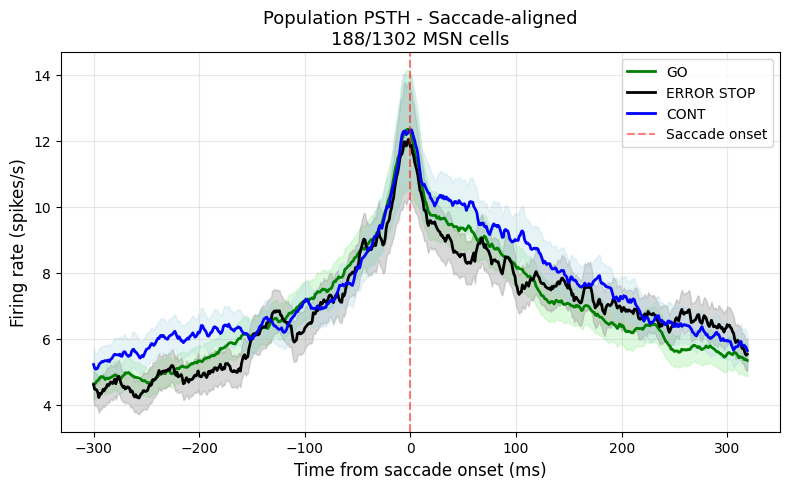

In [202]:
# Extract y_saccade arrays for all trial types and compute mean and SEM
y_saccade_arrays = np.vstack(neuron_stats_df['y_saccade_GO'].values)
y_saccade_stop_arrays = np.vstack(neuron_stats_df['y_saccade_STOP'].values)
y_saccade_cont_arrays = np.vstack(neuron_stats_df['y_saccade_CONT'].values)

mean_y_saccade = np.nanmean(y_saccade_arrays, axis=0)
sem_y_saccade = np.nanstd(y_saccade_arrays, axis=0, ddof=1) / np.sqrt(y_saccade_arrays.shape[0])

mean_y_saccade_stop = np.nanmean(y_saccade_stop_arrays, axis=0)
sem_y_saccade_stop = np.nanstd(y_saccade_stop_arrays, axis=0, ddof=1) / np.sqrt(y_saccade_stop_arrays.shape[0])

mean_y_saccade_cont = np.nanmean(y_saccade_cont_arrays, axis=0)
sem_y_saccade_cont = np.nanstd(y_saccade_cont_arrays, axis=0, ddof=1) / np.sqrt(y_saccade_cont_arrays.shape[0])

# Create x-axis (time points for saccade-aligned data, -100 to +100 ms)
# x_saccade = np.linspace(-300, 300, len(mean_y_saccade))
x_saccade = neuron_stats_df['saccade_time_GO'].iloc[0]

# Plot
fig_saccade, ax_saccade = plt.subplots(figsize=(8, 5))

# GO trials (green)
ax_saccade.plot(x_saccade, mean_y_saccade, color='green', linewidth=2, label='GO')
ax_saccade.fill_between(x_saccade, mean_y_saccade - sem_y_saccade, mean_y_saccade + sem_y_saccade, 
                color='lightgreen', alpha=0.3)

# STOP trials (black)
ax_saccade.plot(x_saccade, mean_y_saccade_stop, color='black', linewidth=2, label='ERROR STOP')
ax_saccade.fill_between(x_saccade, mean_y_saccade_stop - sem_y_saccade_stop, mean_y_saccade_stop + sem_y_saccade_stop, 
                color='gray', alpha=0.3)

# CONT trials (blue)
ax_saccade.plot(x_saccade, mean_y_saccade_cont, color='blue', linewidth=2, label='CONT')
ax_saccade.fill_between(x_saccade, mean_y_saccade_cont - sem_y_saccade_cont, mean_y_saccade_cont + sem_y_saccade_cont, 
                color='lightblue', alpha=0.3)

ax_saccade.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Saccade onset')
ax_saccade.set_xlabel('Time from saccade onset (ms)', fontsize=12)
ax_saccade.set_ylabel('Firing rate (spikes/s)', fontsize=12)
ax_saccade.set_title(f'Population PSTH - Saccade-aligned\n{neuron_stats_df.shape[0]}/{num_of_msn_cells} MSN cells', fontsize=13)
ax_saccade.legend()
ax_saccade.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


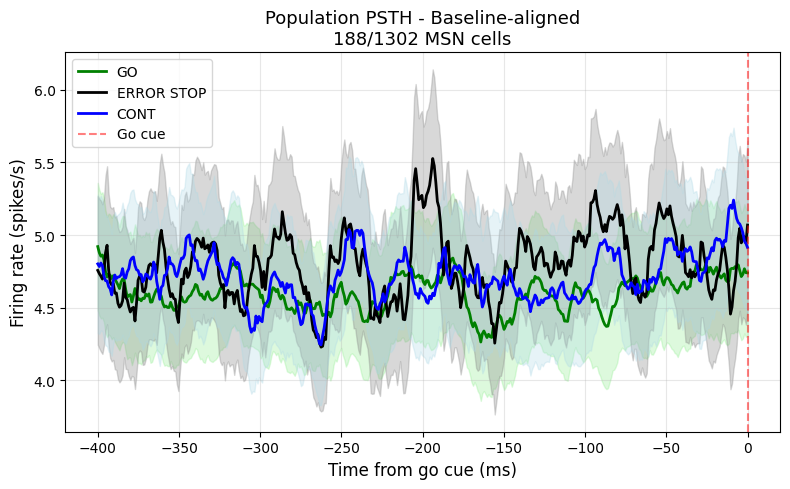

In [203]:
# Extract y_baseline arrays for all trial types and compute mean and SEM
y_baseline_arrays = np.vstack(neuron_stats_df['y_baseline_GO'].values)
y_baseline_stop_arrays = np.vstack(neuron_stats_df['y_baseline_STOP'].values)
y_baseline_cont_arrays = np.vstack(neuron_stats_df['y_baseline_CONT'].values)

mean_y_baseline = np.nanmean(y_baseline_arrays, axis=0)
sem_y_baseline = np.nanstd(y_baseline_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_arrays.shape[0])

mean_y_baseline_stop = np.nanmean(y_baseline_stop_arrays, axis=0)
sem_y_baseline_stop = np.nanstd(y_baseline_stop_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_stop_arrays.shape[0])

mean_y_baseline_cont = np.nanmean(y_baseline_cont_arrays, axis=0)
sem_y_baseline_cont = np.nanstd(y_baseline_cont_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_cont_arrays.shape[0])

# Create x-axis (time points for baseline-aligned data, -400 to 0 ms)
x_baseline = np.linspace(-400, 0, len(mean_y_baseline))

# Plot
fig_baseline, ax_baseline = plt.subplots(figsize=(8, 5))

# GO trials (green)
ax_baseline.plot(x_baseline, mean_y_baseline, color='green', linewidth=2, label='GO')
ax_baseline.fill_between(x_baseline, mean_y_baseline - sem_y_baseline, mean_y_baseline + sem_y_baseline, 
                color='lightgreen', alpha=0.3)

# STOP trials (black)
ax_baseline.plot(x_baseline, mean_y_baseline_stop, color='black', linewidth=2, label='ERROR STOP')
ax_baseline.fill_between(x_baseline, mean_y_baseline_stop - sem_y_baseline_stop, mean_y_baseline_stop + sem_y_baseline_stop, 
                color='gray', alpha=0.3)

# # CONT trials (blue)
ax_baseline.plot(x_baseline, mean_y_baseline_cont, color='blue', linewidth=2, label='CONT')
ax_baseline.fill_between(x_baseline, mean_y_baseline_cont - sem_y_baseline_cont, mean_y_baseline_cont + sem_y_baseline_cont, 
                color='lightblue', alpha=0.3)

ax_baseline.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Go cue')
ax_baseline.set_xlabel('Time from go cue (ms)', fontsize=12)
ax_baseline.set_ylabel('Firing rate (spikes/s)', fontsize=12)
ax_baseline.set_title(f'Population PSTH - Baseline-aligned\n{neuron_stats_df.shape[0]}/{num_of_msn_cells} MSN cells', fontsize=13)
ax_baseline.legend()
ax_baseline.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

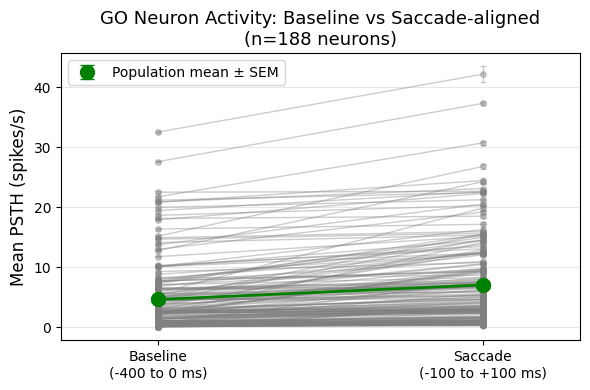

In [204]:
# Create strip plot with lines connecting each neuron
fig, ax = plt.subplots(figsize=(6, 4))
baseline_means_list = []
saccade_means_list = []
# Plot individual neurons in gray with error bars
for idx, row in neuron_stats_df.iterrows():
    # Plot error bars for baseline
    baseline_mean = np.nanmean(row['y_baseline_GO'])
    baseline_sem = np.nanstd(row['y_baseline_GO'], ddof=1) / np.sqrt(len(row['y_baseline_GO']))
    saccade_mean = np.nanmean(row['y_saccade_GO'])
    saccade_sem = np.nanstd(row['y_saccade_GO'], ddof=1) / np.sqrt(len(row['y_saccade_GO']))     
    baseline_means_list.append(baseline_mean)
    saccade_means_list.append(saccade_mean)   
    ax.errorbar([0], [baseline_mean], yerr=[baseline_sem], 
                fmt='o', color='gray', alpha=0.4, markersize=4, capsize=2, linewidth=1)
    # Plot error bars for saccade
    ax.errorbar([1], [saccade_mean], yerr=[saccade_sem], 
                fmt='o', color='gray', alpha=0.4, markersize=4, capsize=2, linewidth=1)
    # Connect with line
    ax.plot([0, 1], [baseline_mean, saccade_mean], 
            '-', color='gray', alpha=0.4, linewidth=1)

pop_baseline_mean = np.mean(baseline_means_list)
pop_baseline_sem = np.std(baseline_means_list, ddof=1) / np.sqrt(len(baseline_means_list))
pop_saccade_mean = np.mean(saccade_means_list)
pop_saccade_sem = np.std(saccade_means_list, ddof=1) / np.sqrt(len(saccade_means_list))
# Plot population mean ± SEM in green
ax.errorbar([0], [pop_baseline_mean], yerr=[pop_baseline_sem], 
            fmt='o', color='green', markersize=10, linewidth=2, capsize=5, label='Population mean ± SEM')
ax.errorbar([1], [pop_saccade_mean], yerr=[pop_saccade_sem], 
            fmt='o', color='green', markersize=10, linewidth=2, capsize=5)
ax.plot([0, 1], [pop_baseline_mean, pop_saccade_mean], 
        '-', color='green', linewidth=2)

# Formatting
ax.set_xlim(-0.3, 1.3)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Baseline\n(-400 to 0 ms)', 'Saccade\n(-100 to +100 ms)'])
ax.set_ylabel('Mean PSTH (spikes/s)', fontsize=12)
ax.set_title(f'GO Neuron Activity: Baseline vs Saccade-aligned\n(n={len(neuron_stats_df)} neurons)', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [205]:

def get_neuron_stats_for_fig2(cell_id: int) -> dict:
    """Calculate mean PSTH and SEM for a single neuron in both conditions"""
    try:
        return_dict = {'cell_ID': cell_id}
        c = Cell(
            cell_df[
                (cell_df["cell_ID"] == cell_id) &
                (cell_df['is_slow_go'].isin([True, np.nan]))  # Only include slow GO trials for condition #1
        ])
        for trial_type in ['GO', 'STOP', 'CONT']:
            # Saccade-aligned condition
            success_var = True #False if trial_type == 'STOP' else True
            bin_centers, firing_rate, _ = c.calculate_psth(
                alignment_point="go_cue",
                epok=[0, 600],
                bin_size=BIN_SIZE,
                smooth_ker_size=SMOOTH_SIGMA,
                success_only=success_var,
                failed_only=not success_var,
                direction=CONTRA_DIR,
                trial_type=trial_type
            )
            
            # Baseline-aligned condition
            ss_bin_centers, ss_firing_rate, _ = c.calculate_psth(
                alignment_point="stop_cue",
                epok=[-300, 600],
                bin_size=BIN_SIZE,
                smooth_ker_size=SMOOTH_SIGMA,
                success_only=success_var,
                failed_only=not success_var,
                direction=CONTRA_DIR,
                trial_type=trial_type
            )
        
            return_dict.update({
                f'y_stop_sig_{trial_type}': ss_firing_rate,
                f'stop_sig_time_{trial_type}': ss_bin_centers,
                f'y_go_cue_{trial_type}': firing_rate,
                f'go_cue_time_{trial_type}': bin_centers
            })
        return return_dict
    except Exception as e:
        print(f"Error processing cell {cell_id}: {e}")
        return None

# Process neurons in parallel
neuron_ids = sorted(list(go_neurons))
print(f"Processing {len(neuron_ids)} neurons in parallel...")

neuron_stats = []
with futures.ProcessPoolExecutor() as executor:
    future_to_neuron = {executor.submit(get_neuron_stats_for_fig2, cid): cid for cid in neuron_ids}
    for future in tqdm(futures.as_completed(future_to_neuron), total=len(neuron_ids), desc="Calculating PSTH stats"):
        result = future.result()
        if result is not None:
            neuron_stats.append(result)

fig_2_stats_df = pd.DataFrame(neuron_stats).sort_values('cell_ID').reset_index(drop=True)

fig_2_stats_df.head()

Processing 188 neurons in parallel...


Calculating PSTH stats: 100%|██████████| 188/188 [00:00<00:00, 211.86it/s]


,cell_ID,y_stop_sig_GO,stop_sig_time_GO,y_go_cue_GO,go_cue_time_GO,y_stop_sig_STOP,stop_sig_time_STOP,y_go_cue_STOP,go_cue_time_STOP,y_stop_sig_CONT,stop_sig_time_CONT,y_go_cue_CONT,go_cue_time_CONT
0,43,"[1.6951860330927808, 1.6127115896417474, 1.534...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.8921973933955794, 1.160...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[2.7779429333980366, 2.6434275195592907, 1.594...","[-300, -299, -298, -297, -296, -295, -294, -29...","[1.67608569438796, 1.5946802286690829, 1.51702...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[4.837154489222572, 4.620974217576744, 4.40251...","[-300, -299, -298, -297, -296, -295, -294, -29...","[5.114185764444824, 5.025886895619849, 4.83715...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,62,"[5.264689886522419, 5.076642460333069, 4.85309...","[-300, -299, -298, -297, -296, -295, -294, -29...","[8.87142032413344, 8.658012074975616, 8.931691...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[7.55253749053572, 8.500056520485597, 8.545973...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[13.308248190315359, 10.591815876383642, 10.07...","[-300, -299, -298, -297, -296, -295, -294, -29...","[3.9530867656334627, 2.7214443705922307, 1.549...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,65,"[1.6650837372611058, 2.860513087186444, 3.1677...","[-300, -299, -298, -297, -296, -295, -294, -29...","[3.2291952608863648, 3.239971245380083, 3.1408...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[2.423604082809403, 2.3054043552668753, 2.1929...","[-300, -299, -298, -297, -296, -295, -294, -29...","[7.172181624838173, 7.135461837022043, 6.89701...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
3,91,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,99,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.283...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[2.863944028089102, 2.8144966615471163, 2.7088...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[1.128565462699886, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


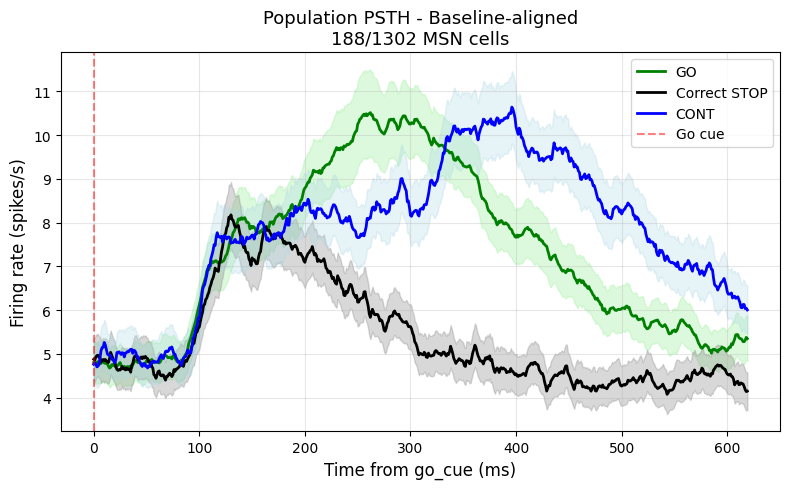

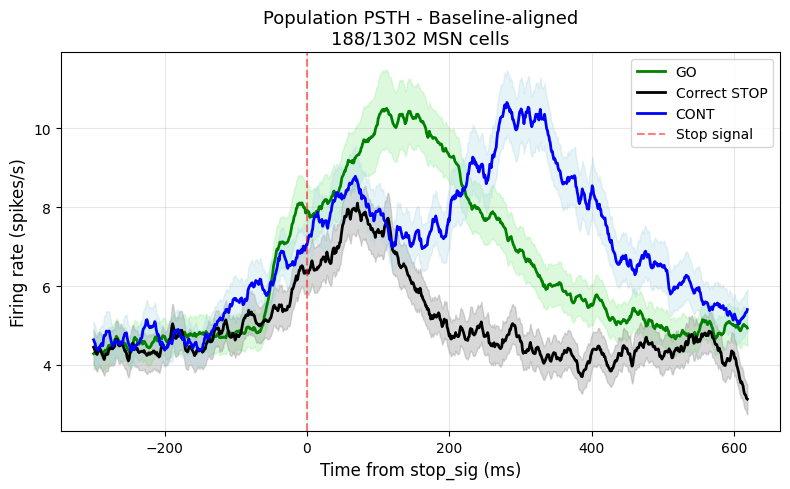

In [206]:
# Extract y_baseline arrays for all trial types and compute mean and SEM
for timeing in ['go_cue', 'stop_sig']:
    y_baseline_arrays = np.vstack(fig_2_stats_df[f'y_{timeing}_GO'].values)
    y_baseline_stop_arrays = np.vstack(fig_2_stats_df[f'y_{timeing}_STOP'].values)
    y_baseline_cont_arrays = np.vstack(fig_2_stats_df[f'y_{timeing}_CONT'].values)

    mean_y_baseline = np.nanmean(y_baseline_arrays, axis=0)
    sem_y_baseline = np.nanstd(y_baseline_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_arrays.shape[0])

    mean_y_baseline_stop = np.nanmean(y_baseline_stop_arrays, axis=0)
    sem_y_baseline_stop = np.nanstd(y_baseline_stop_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_stop_arrays.shape[0])

    mean_y_baseline_cont = np.nanmean(y_baseline_cont_arrays, axis=0)
    sem_y_baseline_cont = np.nanstd(y_baseline_cont_arrays, axis=0, ddof=1) / np.sqrt(y_baseline_cont_arrays.shape[0])

    # Create x-axis (time points for baseline-aligned data, -400 to 0 ms)
    x_baseline = x_saccade = fig_2_stats_df[f'{timeing}_time_GO'].iloc[0]

    # Plot
    fig_baseline, ax_baseline = plt.subplots(figsize=(8, 5))

    # GO trials (green)
    ax_baseline.plot(x_baseline, mean_y_baseline, color='green', linewidth=2, label='GO')
    ax_baseline.fill_between(x_baseline, mean_y_baseline - sem_y_baseline, mean_y_baseline + sem_y_baseline, 
                    color='lightgreen', alpha=0.3)

    # STOP trials (black)
    ax_baseline.plot(x_baseline, mean_y_baseline_stop, color='black', linewidth=2, label='Correct STOP')
    ax_baseline.fill_between(x_baseline, mean_y_baseline_stop - sem_y_baseline_stop, mean_y_baseline_stop + sem_y_baseline_stop, 
                    color='gray', alpha=0.3)

    # # CONT trials (blue)
    ax_baseline.plot(x_baseline, mean_y_baseline_cont, color='blue', linewidth=2, label='CONT')
    ax_baseline.fill_between(x_baseline, mean_y_baseline_cont - sem_y_baseline_cont, mean_y_baseline_cont + sem_y_baseline_cont, 
                    color='lightblue', alpha=0.3)

    ax_baseline.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Go cue' if timeing == 'go_cue' else 'Stop signal')
    ax_baseline.set_xlabel(f'Time from {timeing} (ms)', fontsize=12)
    ax_baseline.set_ylabel('Firing rate (spikes/s)', fontsize=12)
    ax_baseline.set_title(f'Population PSTH - Baseline-aligned\n{fig_2_stats_df.shape[0]}/{num_of_msn_cells} MSN cells', fontsize=13)
    ax_baseline.legend()
    ax_baseline.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [207]:
# Calculate mean PSTH values for each neuron in both conditions
def get_neuron_stats_for_fast_and_slow_comp(cell_id: int) -> dict:
    """Calculate mean PSTH and SEM for a single neuron in both conditions"""
    try:
        return_dict = {'cell_ID': cell_id}

        for condition in ['slow', 'fast']:
            is_slow_go_filter = [True, np.nan] if condition == 'slow' else [False]
            c = Cell(cell_df[
                (cell_df["cell_ID"] == cell_id) &
                (cell_df['is_slow_go'].isin(is_slow_go_filter))
            ])
            for trial_type in ['GO', 'CONT', 'STOP']:
                # Saccade-aligned condition
                success_var = True if trial_type != 'STOP' else False
                bin_centers, firing_rate, _ = c.calculate_psth(
                    alignment_point="first_relevant_saccade",
                    epok=[-300, 300],
                    bin_size=BIN_SIZE,
                    smooth_ker_size=SMOOTH_SIGMA,
                    success_only=success_var,
                    failed_only=not success_var,
                    direction=CONTRA_DIR,
                    trial_type=trial_type
                )
                if firing_rate is None:
                    firing_rate = np.full_like(return_dict['y_saccade_GO_slow'], np.nan)
                return_dict.update({
                    f'y_saccade_{trial_type}_{condition}': firing_rate,
                    f'saccade_time_{trial_type}_{condition}': bin_centers
                })
        return return_dict
    except Exception as e:
        print(f"Error processing cell {cell_id}: {e}")
        return None

# Process neurons in parallel
neuron_ids = sorted(list(go_neurons))
print(f"Processing {len(neuron_ids)} neurons in parallel...")

neuron_stats = []
with futures.ProcessPoolExecutor() as executor:
    future_to_neuron = {executor.submit(get_neuron_stats_for_fast_and_slow_comp, cid): cid for cid in neuron_ids}
    for future in tqdm(futures.as_completed(future_to_neuron), total=len(neuron_ids), desc="Calculating PSTH stats"):
        result = future.result()
        if result is not None:
            neuron_stats.append(result)

fast_and_slow_stats_df = pd.DataFrame(neuron_stats).sort_values('cell_ID').reset_index(drop=True)

fast_and_slow_stats_df.head()

Processing 188 neurons in parallel...


Calculating PSTH stats: 100%|██████████| 188/188 [00:01<00:00, 122.90it/s]


,cell_ID,y_saccade_GO_slow,saccade_time_GO_slow,y_saccade_CONT_slow,saccade_time_CONT_slow,y_saccade_STOP_slow,saccade_time_STOP_slow,y_saccade_GO_fast,saccade_time_GO_fast,y_saccade_CONT_fast,saccade_time_CONT_fast,y_saccade_STOP_fast,saccade_time_STOP_fast
0,43,"[3.7035020701443413, 3.524789366935906, 3.3535...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 3.759974729309941, 4.89235569138827...","[-300, -299, -298, -297, -296, -295, -294, -29...","[9.302301333902983, 8.849313109526818, 8.41796...","[-300, -299, -298, -297, -296, -295, -294, -29...","[2.7247656875017894, 2.6111302105990535, 3.774...","[-300, -299, -298, -297, -296, -295, -294, -29...","[6.758643180368364, 6.430560969929883, 6.11747...","[-300, -299, -298, -297, -296, -295, -294, -29...","[3.3371263609405806, 3.1743729440290442, 5.308...","[-300, -299, -298, -297, -296, -295, -294, -29..."
1,62,"[8.819892697802416, 8.407523571229842, 8.00370...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[3.9322745586494046, 3.3097096936132484, 3.349...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 13.159911552584795, 17.1232449...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29..."
2,65,"[7.470537684654934, 7.195498430265893, 6.87582...","[-300, -299, -298, -297, -296, -295, -294, -29...","[5.111103902064781, 5.048769212117503, 4.86795...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[1.3852538476405047, 1.8024468336693629, 1.884...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.7854223827581...","[-300, -299, -298, -297, -296, -295, -294, -29..."
3,91,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29..."
4,99,"[1.50329647493784, 1.430804861062893, 1.361312...","[-300, -299, -298, -297, -296, -295, -294, -29...","[1.3112058595148395, 1.247257683872939, 1.1864...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.8579468536778898, 0.8161074615492343, 0.776...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-300, -299, -298, -297, -296, -295, -294, -29..."


In [208]:
fast_and_slow_stats_df['y_saccade_STOP_slow'].apply(lambda x: type(x)).value_counts()
fast_and_slow_stats_df.iloc[94]

cell = Cell(cell_df[
    (cell_df['cell_ID'] == 9036) &
    (cell_df['is_slow_go'].isin([True])) & 
    (cell_df['trial_failed'] == True) #&
    # (cell_df['type'] == 'STOP') 
])
cell.data

,cell_ID,cell_type,maestro_ID,problem,grade,filename,trial_name,reaction_time,go_cue,stop_cue,...,saccades,blinks,dir,neural_data,session,plexon_session,trial_number,trial_session,slow_go_thresh,is_slow_go
0,9036,msn,1,NaN,6,fi210718a.0187,GO_R,237.0,1030,NaN,...,"[[103, 133], [1267, 1299], [2173, 2176]]",None,0,"[37.91, 196.06, 233.29, 238.81, 242.84, 262.48...",fi210718,a,187,fi210718a,233,1.0
1,9036,msn,1,NaN,6,fi210718a.0211,GO_R,521.0,996,NaN,...,"[[383, 407], [1517, 1547]]",None,0,"[108.11, 182.49, 194.11, 250.81, 255.86, 324.0...",fi210718,a,211,fi210718a,233,1.0


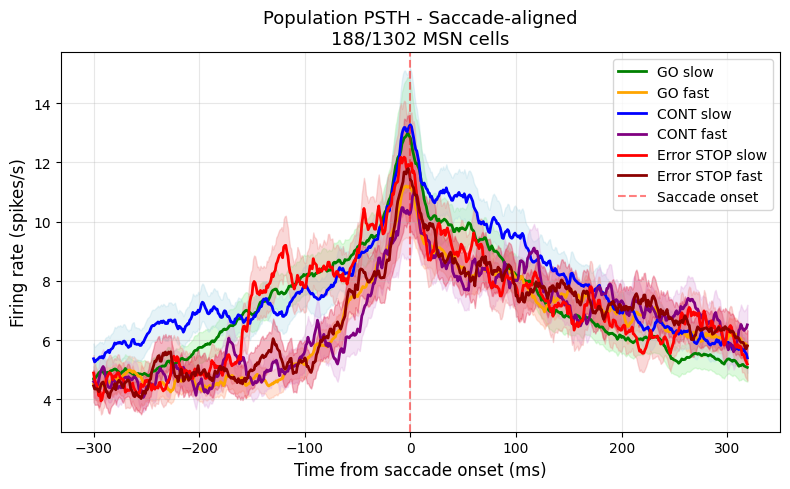

In [209]:
# Extract y_saccade arrays for all trial types and compute mean and SEM
y_go_slow = np.vstack(fast_and_slow_stats_df['y_saccade_GO_slow'].values)
y_go_fast = np.vstack(fast_and_slow_stats_df['y_saccade_GO_fast'].values)
y_cont_slow = np.vstack(fast_and_slow_stats_df['y_saccade_CONT_slow'].values)
y_cont_fast = np.vstack(fast_and_slow_stats_df['y_saccade_CONT_fast'].values)
y_stop_slow = np.vstack(fast_and_slow_stats_df['y_saccade_STOP_slow'].values)
y_stop_fast = np.vstack(fast_and_slow_stats_df['y_saccade_STOP_fast'].values)


mean_y_saccade = np.nanmean(y_go_slow, axis=0)
sem_y_saccade = np.nanstd(y_go_slow, axis=0, ddof=1) / np.sqrt(y_go_slow.shape[0])

mean_y_saccade_fast = np.nanmean(y_go_fast, axis=0)
sem_y_saccade_fast = np.nanstd(y_go_fast, axis=0, ddof=1) / np.sqrt(y_go_fast.shape[0])

mean_y_saccade_cont_slow = np.nanmean(y_cont_slow, axis=0)
sem_y_saccade_cont_slow = np.nanstd(y_cont_slow, axis=0, ddof=1) / np.sqrt(y_cont_slow.shape[0])

mean_y_saccade_cont_fast = np.nanmean(y_cont_fast, axis=0)
sem_y_saccade_cont_fast = np.nanstd(y_cont_fast, axis=0, ddof=1) / np.sqrt(y_cont_fast.shape[0])

mean_y_saccade_stop_slow = np.nanmean(y_stop_slow, axis=0)
sem_y_saccade_stop_slow = np.nanstd(y_stop_slow, axis=0, ddof=1) / np.sqrt(y_stop_slow.shape[0])

mean_y_saccade_stop_fast = np.nanmean(y_stop_fast, axis=0)
sem_y_saccade_stop_fast = np.nanstd(y_stop_fast, axis=0, ddof=1) / np.sqrt(y_stop_fast.shape[0])

# Create x-axis (time points for saccade-aligned data, -100 to +100 ms)
# x_saccade = np.linspace(-300, 300, len(mean_y_saccade))
x_saccade = fast_and_slow_stats_df['saccade_time_GO_slow'].iloc[0]

# Plot
fig_saccade, ax_saccade = plt.subplots(figsize=(8, 5))

# GO slow trials (green)
ax_saccade.plot(x_saccade, mean_y_saccade, color='green', linewidth=2, label='GO slow')
ax_saccade.fill_between(x_saccade, mean_y_saccade - sem_y_saccade, mean_y_saccade + sem_y_saccade, 
                color='lightgreen', alpha=0.3)

# GO fast trials (orange)
ax_saccade.plot(x_saccade, mean_y_saccade_fast, color='orange', linewidth=2, label='GO fast')
ax_saccade.fill_between(x_saccade, mean_y_saccade_fast - sem_y_saccade_fast, mean_y_saccade_fast + sem_y_saccade_fast, 
                color='lightsalmon', alpha=0.3)

# CONT slow trials (blue)
ax_saccade.plot(x_saccade, mean_y_saccade_cont_slow, color='blue', linewidth=2, label='CONT slow')
ax_saccade.fill_between(x_saccade, mean_y_saccade_cont_slow - sem_y_saccade_cont_slow, mean_y_saccade_cont_slow + sem_y_saccade_cont_slow, 
                color='lightblue', alpha=0.3)

# CONT fast trials (purple)
ax_saccade.plot(x_saccade, mean_y_saccade_cont_fast, color='purple', linewidth=2, label='CONT fast')
ax_saccade.fill_between(x_saccade, mean_y_saccade_cont_fast - sem_y_saccade_cont_fast, mean_y_saccade_cont_fast + sem_y_saccade_cont_fast, 
                color='plum', alpha=0.3)

# STOP slow trials (red)
ax_saccade.plot(x_saccade, mean_y_saccade_stop_slow, color='red', linewidth=2, label='Error STOP slow')
ax_saccade.fill_between(x_saccade, mean_y_saccade_stop_slow - sem_y_saccade_stop_slow, mean_y_saccade_stop_slow + sem_y_saccade_stop_slow, 
                color='lightcoral', alpha=0.3)

# STOP fast trials (dark red)
ax_saccade.plot(x_saccade, mean_y_saccade_stop_fast, color='darkred', linewidth=2, label='Error STOP fast')
ax_saccade.fill_between(x_saccade, mean_y_saccade_stop_fast - sem_y_saccade_stop_fast, mean_y_saccade_stop_fast + sem_y_saccade_stop_fast, 
                color='crimson', alpha=0.3)

ax_saccade.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Saccade onset')
ax_saccade.set_xlabel('Time from saccade onset (ms)', fontsize=12)
ax_saccade.set_ylabel('Firing rate (spikes/s)', fontsize=12)
ax_saccade.set_title(f'Population PSTH - Saccade-aligned\n{fast_and_slow_stats_df.shape[0]}/{num_of_msn_cells} MSN cells', fontsize=13)
ax_saccade.legend()
ax_saccade.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4.1

In [210]:
mean_go_RT = np.nanmean(
        cell_df[
        cell_df['cell_ID'].isin(go_neurons) & 
        (cell_df['trial_failed'] == False) &
        (cell_df['type'] == 'GO') &
        (cell_df['is_slow_go'] == True)  # Only slow GO trials
    ].drop_duplicates('filename')['reaction_time']
)

mean_error_stop_RT = np.nanmean(
        cell_df[
        cell_df['cell_ID'].isin(go_neurons) & 
        (cell_df['trial_failed'] == True) &
        (cell_df['type'] == 'STOP')
    ].drop_duplicates('filename')['reaction_time']
)

mean_cont_RT = np.nanmean(
        cell_df[
        cell_df['cell_ID'].isin(go_neurons) & 
        (cell_df['type'] == 'CONT') &
        (cell_df['trial_failed'] == False) &
        (cell_df['is_slow_go'] == True)  # Only slow CONT trials
    ].drop_duplicates('filename')['reaction_time']
)   

print(f"Mean GO RT: {mean_go_RT:.2f} ms")
print(f"Mean ERROR STOP RT: {mean_error_stop_RT:.2f} ms")
print(f"Mean CONT RT: {mean_cont_RT:.2f} ms")

Mean GO RT: 280.50 ms
Mean ERROR STOP RT: 203.69 ms
Mean CONT RT: 333.33 ms


In [220]:
go_mean_rt = np.nanmean(
    cell_df[
        (cell_df['trial_failed'] == False) &
        (cell_df['type'] == 'GO') &
        (cell_df['dir'] == CONTRA_DIR) 
    ].drop_duplicates('filename')['reaction_time']
)

cont_mean_rt = np.nanmean(
    cell_df[
        (cell_df['trial_failed'] == False) &
        (cell_df['type'] == 'CONT') &
        (cell_df['dir'] == CONTRA_DIR) 
    ].drop_duplicates('filename')['reaction_time']
)

err_stop_mean_rt = np.nanmean(
    cell_df[
        (cell_df['trial_failed'] == True) &
        (cell_df['type'] == 'STOP') &
        (cell_df['dir'] == CONTRA_DIR) 
    ].drop_duplicates('filename')['reaction_time']
)

print("Fiona:")
print(f"Mean GO RT: {go_mean_rt:.2f} ms - calculated across all successful GO trials in contralateral direction")
print(f"Mean CONT RT: {cont_mean_rt:.2f} ms - calculated across all successful CONT trials in contralateral direction")
print(f"Mean ERROR STOP RT: {err_stop_mean_rt:.2f} ms - calculated across all ERROR STOP trials in contralateral direction")

Fiona:
Mean GO RT: 241.13 ms - calculated across all successful GO trials in contralateral direction
Mean CONT RT: 285.00 ms - calculated across all successful CONT trials in contralateral direction
Mean ERROR STOP RT: 205.09 ms - calculated across all ERROR STOP trials in contralateral direction


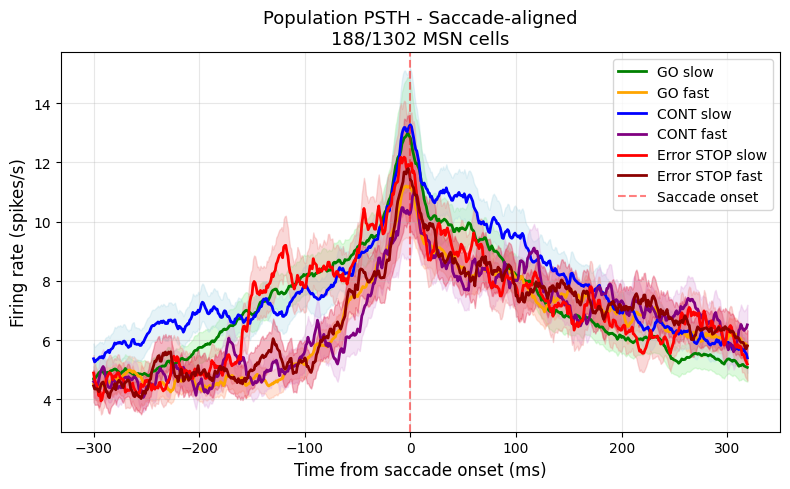

In [212]:
fig_saccade

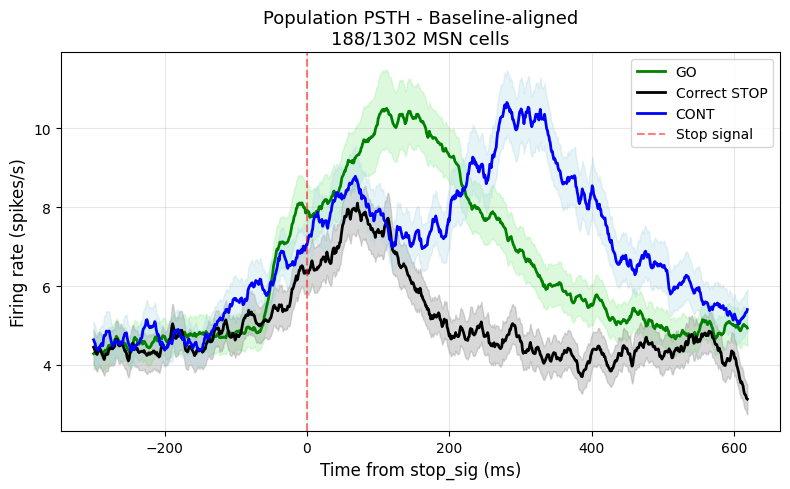

In [213]:
fig_baseline

In [214]:
# cell_df = pd.read_pickle(pickle_file)


In [215]:
# cell = Cell(cell_df[cell_df['cell_ID'] == list(go_neurons)[0]])
# bin_centers, firing_rate, n_trials = cell.calculate_psth(
#     alignment_point='first_relevant_saccade',
#     epok=[-350, 350],
#     bin_size=1,
#     smooth_ker_size=SMOOTH_SIGMA,
#     trial_type='STOP',
#     direction=CONTRA_DIR,
#     success_only=False
# )
# print
# plt.figure(figsize=(8, 5))
# plt.plot(bin_centers, firing_rate, color='purple', label='STOP trials')
# plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Saccade onset')
# # plt.xlabel('Time from saccade onset (ms)', fontsize=12)
# plt.ylabel('Firing rate (spikes/s)', fontsize=12)
# plt.title(f'Example GO Neuron - STOP trials\nCell ID: {cell.cell_id}', fontsize=13)
# plt.legend()
# plt.grid(True, alpha=0.3)   